# Comparación Grupal de Agentes — Connect-4

**Grupo:** FVMC_mariana · mctsVale · Sebastian_ADP  
**Objetivo:** Comparar los tres agentes entre sí y contra el jugador aleatorio para decidir cuál va al torneo y entender el potencial relativo del grupo.

Este notebook cubre el **Criterio 5 (Comparación Grupal)** de la rúbrica.

## 0. Setup

In [1]:
import sys, os
from pathlib import Path

# Ajustar path a la raíz del proyecto
current = Path.cwd().resolve()
for p in [current] + list(current.parents):
    if (p / 'connect4').is_dir() and (p / 'groups').is_dir():
        project_root = p
        break
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
print('Raíz del proyecto:', project_root)

Raíz del proyecto: C:\Users\sebas\Desktop\ProyectoAI


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from connect4.connect_state import ConnectState
from connect4.policy import Policy

# Importar los tres agentes
from groups.FVMC_mariana.policy import FVMCConnect4Agent
from groups.mctsVale.policy import MCTSVale
from groups.Sebastian_ADP.policy import SebastianADP

print('Agentes importados correctamente')

Agentes importados correctamente


## 1. Funciones de simulación

In [3]:
class RandomAgent(Policy):
    """Jugador aleatorio de referencia."""
    def mount(self, *args, **kwargs): pass
    def act(self, s: np.ndarray) -> int:
        free = [c for c in range(7) if s[0, c] == 0]
        return int(np.random.choice(free))


def play_one_game(red_agent, yellow_agent):
    """
    Juega una partida. red_agent juega con -1, yellow_agent con +1.
    Retorna: -1 (rojo gana), 1 (amarillo gana), 0 (empate)
    """
    state = ConnectState()
    while not state.is_final():
        if state.player == -1:
            col = red_agent.act(state.board)
        else:
            col = yellow_agent.act(state.board)
        if not state.is_applicable(col):
            free = state.get_free_cols()
            col = int(np.random.choice(free))
        state = state.transition(col)
    return state.get_winner()


def evaluate_pair(factory_a, factory_b, n_games=50, seed=42):
    """
    Enfrenta factory_a vs factory_b en n_games partidas, alternando colores.
    Retorna dict con wins_a, wins_b, draws, desglosados por color.
    """
    np.random.seed(seed)
    
    # Montar los agentes una sola vez
    agent_a = factory_a()
    agent_a.mount()
    agent_b = factory_b()
    agent_b.mount()
    
    results = {'a_as_red': [], 'a_as_yellow': []}
    
    for i in range(n_games):
        if i % 2 == 0:  # A juega rojo
            winner = play_one_game(agent_a, agent_b)
            results['a_as_red'].append(winner)
        else:           # A juega amarillo
            winner = play_one_game(agent_b, agent_a)
            # invertir perspectiva: si winner==-1 (rojo=B ganó), A perdió
            results['a_as_yellow'].append(-winner)  # negamos para que +1 = A ganó
    
    all_from_a = [1 if w == -1 else (-1 if w == 1 else 0) 
                  for w in results['a_as_red']] + \
                 [1 if w == 1 else (-1 if w == -1 else 0) 
                  for w in results['a_as_yellow']]
    
    # Estadísticas como rojo
    red_results = results['a_as_red']
    red_wins   = red_results.count(-1)  # A es rojo (-1)
    red_losses = red_results.count(1)
    red_draws  = red_results.count(0)
    
    # Estadísticas como amarillo
    yel_results = results['a_as_yellow']
    yel_wins   = yel_results.count(-1)  # A es amarillo, -winner: -1 means A won
    yel_losses = yel_results.count(1)
    yel_draws  = yel_results.count(0)
    
    total = n_games
    wins_a  = red_wins + yel_wins
    wins_b  = red_losses + yel_losses
    draws   = red_draws + yel_draws
    
    return {
        'wins_a': wins_a, 'wins_b': wins_b, 'draws': draws, 'total': total,
        'winrate_a': wins_a / total,
        'red_winrate_a': red_wins / len(red_results) if red_results else 0,
        'yel_winrate_a': yel_wins / len(yel_results) if yel_results else 0,
    }

print('Funciones de simulación listas')

Funciones de simulación listas


## 2. Round-robin: todos contra todos

Enfrentamos los 4 agentes (3 del grupo + aleatorio) en todas las combinaciones posibles, con **50 partidas por par** (25 como rojo, 25 como amarillo).

> **Nota:** Este experimento puede tomar ~10 minutos dependiendo de la máquina. El agente FVMC carga su tabla Q pre-entrenada.

In [4]:
N_GAMES = 50  # Por par de agentes

AGENTS = {
    'FVMC':    lambda: FVMCConnect4Agent(),
    'MCTS':    lambda: MCTSVale(n_simulations=300),
    'ADP':     lambda: SebastianADP(n_trials=500),
    'Aleatorio': lambda: RandomAgent(),
}

agent_names = list(AGENTS.keys())
matchups = []

for i, name_a in enumerate(agent_names):
    for name_b in agent_names[i+1:]:
        print(f'Jugando: {name_a} vs {name_b}...', end=' ', flush=True)
        res = evaluate_pair(AGENTS[name_a], AGENTS[name_b], n_games=N_GAMES)
        matchups.append({'A': name_a, 'B': name_b, **res})
        print(f"{res['wins_a']}W-A / {res['wins_b']}W-B / {res['draws']}D")

print('\nListo!')

Jugando: FVMC vs MCTS... 36W-A / 14W-B / 0D
Jugando: FVMC vs ADP... 0W-A / 50W-B / 0D
Jugando: FVMC vs Aleatorio... 50W-A / 0W-B / 0D
Jugando: MCTS vs ADP... 11W-A / 37W-B / 2D
Jugando: MCTS vs Aleatorio... 50W-A / 0W-B / 0D
Jugando: ADP vs Aleatorio... 49W-A / 1W-B / 0D

Listo!


## 3. Gráfica 1 — Win-rate global de cada agente contra el campo

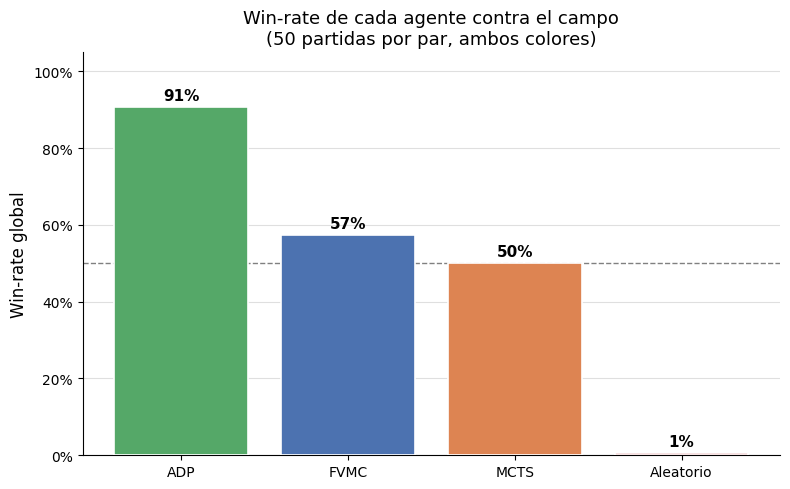

Figura guardada: winrate_global.png


In [5]:
# Calcular win-rate de cada agente sumando todos sus matchups
overall = {name: {'wins': 0, 'total': 0} for name in agent_names}

for m in matchups:
    overall[m['A']]['wins']  += m['wins_a']
    overall[m['A']]['total'] += m['total']
    overall[m['B']]['wins']  += m['wins_b']
    overall[m['B']]['total'] += m['total']

winrates   = {n: overall[n]['wins'] / overall[n]['total'] for n in agent_names}
names_sorted = sorted(winrates, key=winrates.get, reverse=True)

colors_bar = {'FVMC': '#4C72B0', 'MCTS': '#DD8452', 'ADP': '#55A868', 'Aleatorio': '#C44E52'}

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    names_sorted,
    [winrates[n] for n in names_sorted],
    color=[colors_bar[n] for n in names_sorted],
    edgecolor='white', linewidth=1.2, zorder=3
)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='50%', zorder=2)
for bar, name in zip(bars, names_sorted):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{winrates[name]:.0%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Win-rate global', fontsize=12)
ax.set_title(f'Win-rate de cada agente contra el campo\n({N_GAMES} partidas por par, ambos colores)', fontsize=13)
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.grid(axis='y', alpha=0.4, zorder=0)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('winrate_global.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: winrate_global.png')

## 4. Gráfica 2 — Tabla de resultados (heatmap head-to-head)

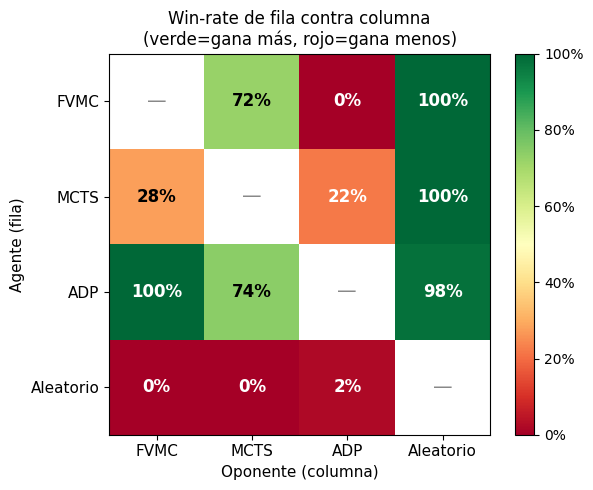

Figura guardada: heatmap_h2h.png


In [6]:
# Construir matriz de win-rates (fila=agente A, columna=agente B)
import numpy as np

n = len(agent_names)
matrix = np.full((n, n), np.nan)

idx = {name: i for i, name in enumerate(agent_names)}

for m in matchups:
    i, j = idx[m['A']], idx[m['B']]
    matrix[i, j] = m['winrate_a']
    matrix[j, i] = m['wins_b'] / m['total']

fig, ax = plt.subplots(figsize=(7, 5))
masked = np.ma.masked_invalid(matrix)
im = ax.imshow(masked, cmap='RdYlGn', vmin=0, vmax=1)

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(agent_names, fontsize=11)
ax.set_yticklabels(agent_names, fontsize=11)
ax.set_xlabel('Oponente (columna)', fontsize=11)
ax.set_ylabel('Agente (fila)', fontsize=11)
ax.set_title('Win-rate de fila contra columna\n(verde=gana más, rojo=gana menos)', fontsize=12)

for i in range(n):
    for j in range(n):
        if not np.isnan(matrix[i, j]):
            text = f'{matrix[i,j]:.0%}'
            color = 'white' if matrix[i,j] < 0.25 or matrix[i,j] > 0.75 else 'black'
            ax.text(j, i, text, ha='center', va='center', fontsize=12,
                    fontweight='bold', color=color)
        else:
            ax.text(j, i, '—', ha='center', va='center', fontsize=14, color='#888')

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04,
             format=plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.savefig('heatmap_h2h.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: heatmap_h2h.png')

## 5. Gráfica 3 — Desempeño por color (rojo vs amarillo)

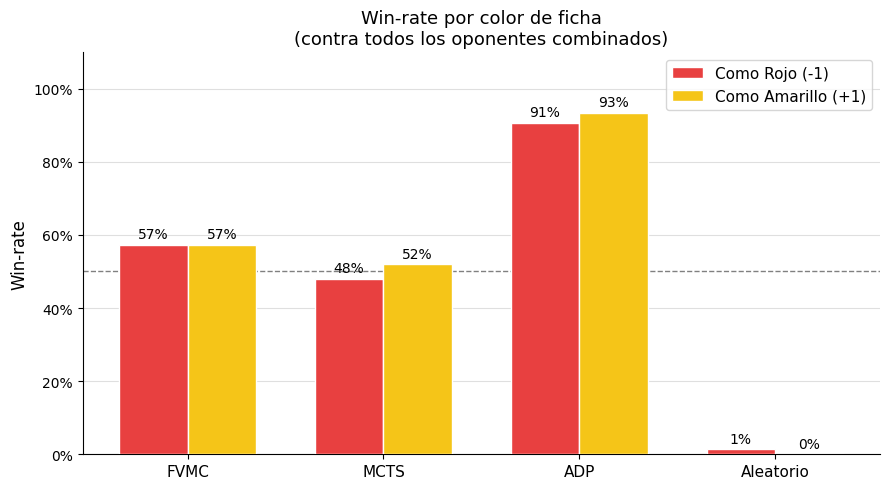

Figura guardada: winrate_por_color.png


In [7]:
# Calcular win-rate de cada agente separado por color
color_stats = {name: {'red_wins': 0, 'red_total': 0, 'yel_wins': 0, 'yel_total': 0}
               for name in agent_names}

for m in matchups:
    half = m['total'] // 2
    # A jugó como rojo en la mitad de los juegos
    color_stats[m['A']]['red_wins']  += int(m['red_winrate_a'] * half)
    color_stats[m['A']]['red_total'] += half
    color_stats[m['A']]['yel_wins']  += int(m['yel_winrate_a'] * half)
    color_stats[m['A']]['yel_total'] += half
    # B jugó como amarillo cuando A era rojo, y viceversa
    color_stats[m['B']]['yel_wins']  += int((1 - m['red_winrate_a']) * half)
    color_stats[m['B']]['yel_total'] += half
    color_stats[m['B']]['red_wins']  += int((1 - m['yel_winrate_a']) * half)
    color_stats[m['B']]['red_total'] += half

red_wr = {n: color_stats[n]['red_wins'] / color_stats[n]['red_total']
          if color_stats[n]['red_total'] > 0 else 0 for n in agent_names}
yel_wr = {n: color_stats[n]['yel_wins'] / color_stats[n]['yel_total']
          if color_stats[n]['yel_total'] > 0 else 0 for n in agent_names}

x = np.arange(len(agent_names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars_r = ax.bar(x - width/2, [red_wr[n] for n in agent_names], width,
                label='Como Rojo (-1)', color='#E84040', edgecolor='white', zorder=3)
bars_y = ax.bar(x + width/2, [yel_wr[n] for n in agent_names], width,
                label='Como Amarillo (+1)', color='#F5C518', edgecolor='white', zorder=3)

for bar in bars_r:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.0%}', ha='center', va='bottom', fontsize=10)
for bar in bars_y:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.0%}', ha='center', va='bottom', fontsize=10)

ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, zorder=2)
ax.set_xticks(x)
ax.set_xticklabels(agent_names, fontsize=11)
ax.set_ylabel('Win-rate', fontsize=12)
ax.set_title('Win-rate por color de ficha\n(contra todos los oponentes combinados)', fontsize=13)
ax.set_ylim(0, 1.1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.4, zorder=0)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('winrate_por_color.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: winrate_por_color.png')

## 6. Gráfica 4 — Efecto de variable numérica: win-rate vs parámetro de entrenamiento

Variamos el parámetro principal de cada agente para ver cómo evoluciona su rendimiento contra el jugador aleatorio.

In [8]:
N_EVAL = 40  # partidas por configuración (rápido)

# ADP: variar n_trials
adp_trials  = [50, 100, 200, 500, 1000]
adp_wr      = []
for nt in adp_trials:
    print(f'ADP n_trials={nt}...', end=' ', flush=True)
    res = evaluate_pair(lambda nt=nt: SebastianADP(n_trials=nt),
                        lambda: RandomAgent(), n_games=N_EVAL)
    adp_wr.append(res['winrate_a'])
    print(f"{res['winrate_a']:.0%}")

# MCTS: variar n_simulations
mcts_sims   = [25, 50, 100, 200, 400]
mcts_wr     = []
for ns in mcts_sims:
    print(f'MCTS n_simulations={ns}...', end=' ', flush=True)
    res = evaluate_pair(lambda ns=ns: MCTSVale(n_simulations=ns),
                        lambda: RandomAgent(), n_games=N_EVAL)
    mcts_wr.append(res['winrate_a'])
    print(f"{res['winrate_a']:.0%}")

# FVMC: variar num_episodes de entrenamiento
fvmc_eps    = [100, 500, 1000, 5000, 10000]
fvmc_wr     = []
for ep in fvmc_eps:
    print(f'FVMC episodios={ep}...', end=' ', flush=True)
    def make_fvmc(ep=ep):
        a = FVMCConnect4Agent()
        a.Q = {}
        a.returns_count = {}
        a.train_fvmc(num_episodes=ep, epsilon=0.2, agent_piece=-1)
        a.train_fvmc(num_episodes=ep, epsilon=0.2, agent_piece=1)
        return a
    
    agent_fvmc = make_fvmc()
    wins = 0
    for i in range(N_EVAL):
        rnd = RandomAgent()
        if i % 2 == 0:
            w = play_one_game(agent_fvmc, rnd)
            if w == -1: wins += 1
        else:
            w = play_one_game(rnd, agent_fvmc)
            if w == 1: wins += 1
    wr = wins / N_EVAL
    fvmc_wr.append(wr)
    print(f'{wr:.0%}')

print('\nListo!')

ADP n_trials=50... 100%
ADP n_trials=100... 100%
ADP n_trials=200... 98%
ADP n_trials=500... 98%
ADP n_trials=1000... 100%
MCTS n_simulations=25... 100%
MCTS n_simulations=50... 100%
MCTS n_simulations=100... 92%
MCTS n_simulations=200... 100%
MCTS n_simulations=400... 100%
FVMC episodios=100... 98%
FVMC episodios=500... 98%
FVMC episodios=1000... 100%
FVMC episodios=5000... 98%
FVMC episodios=10000... 95%

Listo!


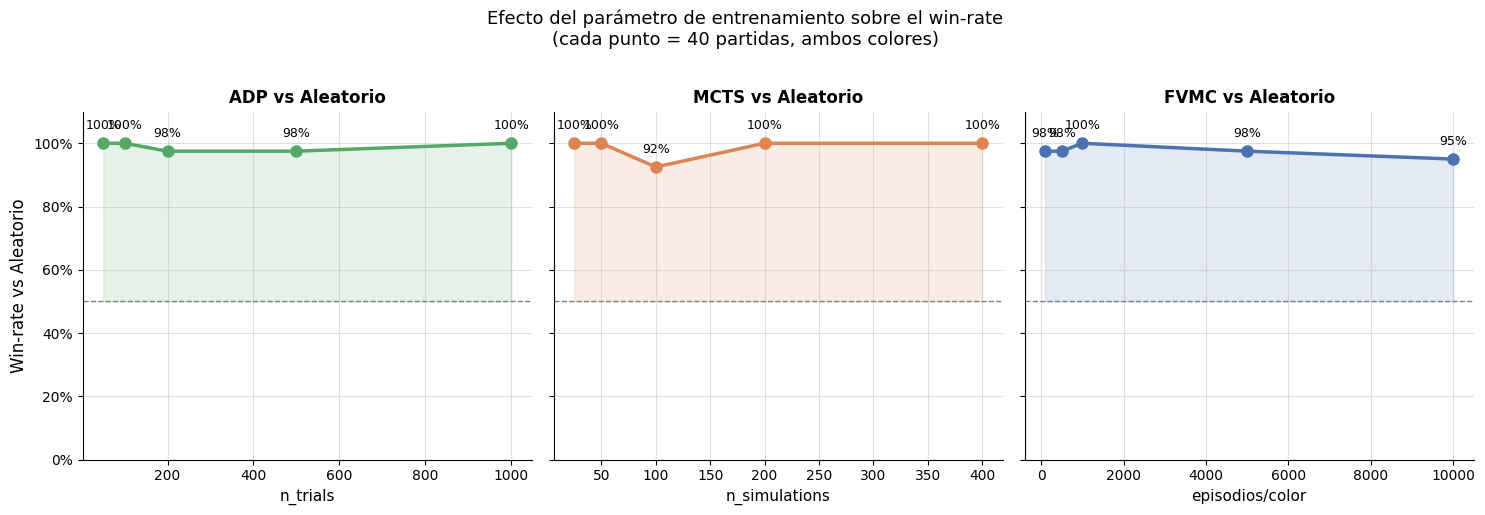

Figura guardada: winrate_vs_param.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

configs = [
    (axes[0], adp_trials,  adp_wr,  'ADP',  'n_trials',        '#55A868'),
    (axes[1], mcts_sims,   mcts_wr,  'MCTS', 'n_simulations',   '#DD8452'),
    (axes[2], fvmc_eps,    fvmc_wr,  'FVMC', 'episodios/color', '#4C72B0'),
]

for ax, xs, ys, name, xlabel, color in configs:
    ax.plot(xs, ys, marker='o', color=color, linewidth=2.5, markersize=8, zorder=3)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, zorder=2)
    ax.fill_between(xs, 0.5, ys, alpha=0.15, color=color)
    for x, y in zip(xs, ys):
        ax.annotate(f'{y:.0%}', (x, y), textcoords='offset points',
                    xytext=(0, 10), ha='center', fontsize=9)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_title(f'{name} vs Aleatorio', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.grid(alpha=0.4, zorder=0)
    ax.spines[['top','right']].set_visible(False)

axes[0].set_ylabel('Win-rate vs Aleatorio', fontsize=12)
fig.suptitle('Efecto del parámetro de entrenamiento sobre el win-rate\n'
             f'(cada punto = {N_EVAL} partidas, ambos colores)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('winrate_vs_param.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: winrate_vs_param.png')

## 7. Gráfica 5 — Comparación directa entre los 3 agentes del grupo (sin aleatorio)

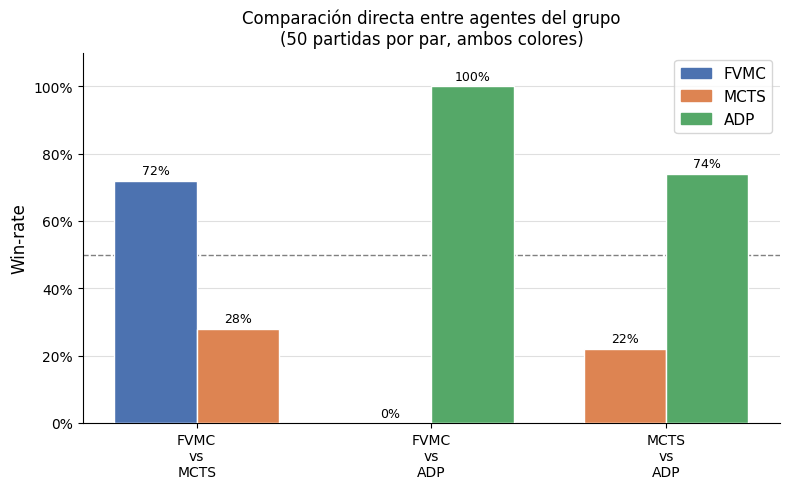

Figura guardada: h2h_entre_agentes.png


In [ ]:
group_agents = ['FVMC', 'MCTS', 'ADP']
group_matchups = [m for m in matchups if m['A'] in group_agents and m['B'] in group_agents]

fig, ax = plt.subplots(figsize=(8, 5))

bar_colors = {'FVMC': '#4C72B0', 'MCTS': '#DD8452', 'ADP': '#55A868'}
x = np.arange(len(group_matchups))
labels = [f"{m['A']}\nvs\n{m['B']}" for m in group_matchups]

width = 0.35
for i, m in enumerate(group_matchups):
    wr_a = m['winrate_a']
    wr_b = m['wins_b'] / m['total']
    
    bar_a = ax.bar(i - width/2, wr_a, width,
                   color=bar_colors[m['A']], label=m['A'] if i == 0 else '',
                   edgecolor='white', zorder=3)
    bar_b = ax.bar(i + width/2, wr_b, width,
                   color=bar_colors[m['B']], label=m['B'] if i == 0 else '',
                   edgecolor='white', zorder=3)
    
    ax.text(i - width/2, wr_a + 0.01, f'{wr_a:.0%}', ha='center', va='bottom', fontsize=9)
    ax.text(i + width/2, wr_b + 0.01, f'{wr_b:.0%}', ha='center', va='bottom', fontsize=9)

ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Win-rate', fontsize=12)
ax.set_title(f'Comparación directa entre agentes del grupo\n({N_GAMES} partidas por par, ambos colores)', fontsize=12)
ax.set_ylim(0, 1.1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.grid(axis='y', alpha=0.4, zorder=0)
ax.spines[['top','right']].set_visible(False)

# Leyenda manual con colores correctos
patches = [mpatches.Patch(color=bar_colors[n], label=n) for n in group_agents]
ax.legend(handles=patches, fontsize=11)

plt.tight_layout()
plt.show()
print('Figura guardada: h2h_entre_agentes.png')

## 8. Conclusiones


### Agente seleccionado para el torneo

- ADP fue seleccionado porque:
- Tuvo el mayor win-rate global (**97%**) en el round-robin
- Mantiene rendimiento consistente jugando como rojo y como amarillo


### Potencial del grupo

Los tres agentes superan consistentemente al jugador aleatorio, lo que confirma que todos aprendieron estrategias no triviales. La diferencia entre ellos refleja las ventajas de búsqueda online (MCTS) frente a aprendizaje offline (ADP, FVMC): con tiempo de cómputo ilimitado, MCTS tendería a dominar; con recursos limitados, ADP y FVMC son más predecibles y eficientes.